# HW06 — Decision Trees & Ensembles + Honest ML Experiment (S06)

**Датасет:** `S06-hw-dataset-01.csv` (бинарная классификация)

В этом ноутбуке:
- делаем базовый EDA;
- фиксируем **train/test split** (с seed и стратификацией);
- строим baseline'ы: `DummyClassifier`, `LogisticRegression`;
- сравниваем минимум 3 модели недели 6: `DecisionTree`, `RandomForest`, `GradientBoosting`;
- гиперпараметры подбираем **только на train через CV**;
- test используем **один раз** для финальной оценки;
- сохраняем артефакты в `homeworks/HW06/artifacts/`.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_FILENAME = "S06-hw-dataset-01.csv"
candidates = [
    Path(DATA_FILENAME),
    Path("homeworks") / "HW06" / DATA_FILENAME,
]
for c in candidates:
    if c.exists():
        DATA_PATH = c
        break
else:
    raise FileNotFoundError(
        f"Не найден {DATA_FILENAME}. Проверить, что файл лежит рядом с ноутбуком "
        f"или в homeworks/HW06/."
    )

BASE_DIR = DATA_PATH.resolve().parent
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Resolved DATA_PATH:", DATA_PATH)
print("Resolved ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("Resolved FIGURES_DIR:", FIGURES_DIR)


Resolved DATA_PATH: S06-hw-dataset-01.csv
Resolved ARTIFACTS_DIR: C:\Users\anark\am-nom3\homeworks\HW06\artifacts
Resolved FIGURES_DIR: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\figures


## 1) Загрузка данных и первичный анализ

Минимум: `head()`, `info()`, `describe()`, распределение `target`, проверка пропусков.


In [ ]:
df = pd.read_csv(DATA_PATH)

display(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescribe (numeric):")
display(df.describe(include=[np.number]).T)

na_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top):")
display(na_counts.head(20))

target_counts = df["target"].value_counts(dropna=False)
target_share = df["target"].value_counts(normalize=True, dropna=False)
print("\nTarget counts:")
display(target_counts)
print("\nTarget share:")
display(target_share)

print("\nDtypes:")
display(df.dtypes.value_counts())


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0



Shape: (12000, 30)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 no

,count,mean,std,min,25%,50%,75%,max
id,12000.0,6000.500000,3464.245950,1.000000,3000.750000,6000.500000,9000.250000,12000.000000
num01,12000.0,0.013705,2.096534,-8.155181,-1.423844,-0.047565,1.422676,8.610863
num02,12000.0,-0.005278,3.544498,-14.605579,-2.303772,0.053348,2.335937,16.299709
num03,12000.0,-0.002357,1.004417,-4.374043,-0.685618,-0.009186,0.671441,3.651692
num04,12000.0,0.038404,2.087318,-7.753301,-1.374579,0.038766,1.484417,7.571965
num05,12000.0,-0.006301,1.007329,-3.999332,-0.676552,-0.003728,0.669269,4.562115
num06,12000.0,-0.865297,3.888966,-15.238402,-3.532054,-1.092517,1.526389,16.223054
num07,12000.0,-0.702877,1.989513,-7.377252,-2.064888,-0.795907,0.522625,8.006444
num08,12000.0,-0.290694,3.455981,-13.853627,-2.597019,-0.208245,2.093169,13.030011
num09,12000.0,-0.008154,0.996677,-3.794637,-0.683959,-0.020883,0.666959,3.976868



Missing values (top):


id       0
num01    0
num02    0
num03    0
num04    0
num05    0
num06    0
num07    0
num08    0
num09    0
num10    0
num11    0
num12    0
num13    0
num14    0
num15    0
num16    0
num17    0
num18    0
num19    0
dtype: int64

...

target
0    8119
1    3881
Name: count, dtype: int64


Target share:


target
0    0.676583
1    0.323417
Name: proportion, dtype: float64


Dtypes:


float64    24
int64       6
Name: count, dtype: int64

### Определяем X и y

- `y` = `target`
- `X` = все остальные столбцы, **кроме** `target`
- столбец `id` **не используем как признак**


In [12]:
assert "target" in df.columns, "Ожидается столбец 'target'"
assert "id" in df.columns, "Ожидается столбец 'id' (его не используем как признак)"

X = df.drop(columns=["target", "id"])
y = df["target"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))


X shape: (12000, 28)
y shape: (12000,)
Classes: [0 1]


## 2) Train/Test split и воспроизводимость

Почему важно:
- фиксированный `random_state` делает эксперимент воспроизводимым;
- `stratify=y` сохраняет доли классов в train/test (важно для дисбаланса и честной оценки).


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Target share train:", np.bincount(y_train)/len(y_train))
print("Target share test :", np.bincount(y_test)/len(y_test))


Train: (9000, 28) Test: (3000, 28)
Target share train: [0.67655556 0.32344444]
Target share test : [0.67666667 0.32333333]


## Вспомогательные функции: метрики и графики

Для бинарной классификации считаем:
- `accuracy`
- `f1`
- `roc_auc` (по вероятностям положительного класса)


In [ ]:
def evaluate_binary(model, X_te, y_te):
    """Return dict with accuracy, f1, roc_auc (+ proba if available)."""
    y_pred = model.predict(X_te)
    out = {
        "accuracy": float(accuracy_score(y_te, y_pred)),
        "f1": float(f1_score(y_te, y_pred)),
    }
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
        out["roc_auc"] = float(roc_auc_score(y_te, y_proba))
        out["_y_proba"] = y_proba
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
        out["roc_auc"] = float(roc_auc_score(y_te, y_score))
        out["_y_proba"] = y_score
    else:
        out["roc_auc"] = None
        out["_y_proba"] = None
    return out

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_and_save_roc(y_true, y_score, title, path_png):
    RocCurveDisplay.from_predictions(y_true, y_score, name=title)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path_png, dpi=150)
    plt.show()

def plot_and_save_cm(model, X_te, y_te, title, path_png):
    ConfusionMatrixDisplay.from_estimator(model, X_te, y_te)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path_png, dpi=150)
    plt.show()


Dummy metrics: {'accuracy': 0.6766666666666666, 'f1': 0.0, 'roc_auc': 0.5}
LogReg metrics: {'accuracy': 0.8296666666666667, 'f1': 0.7146845337800112, 'roc_auc': 0.8789091463104972}


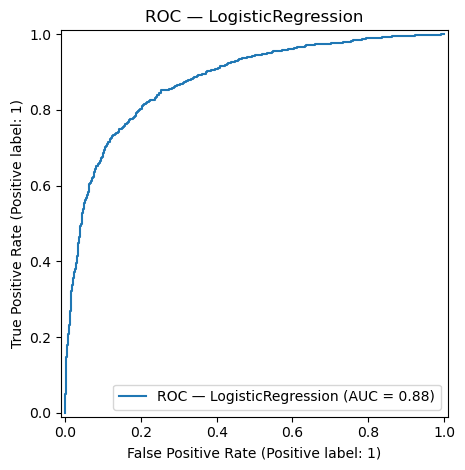

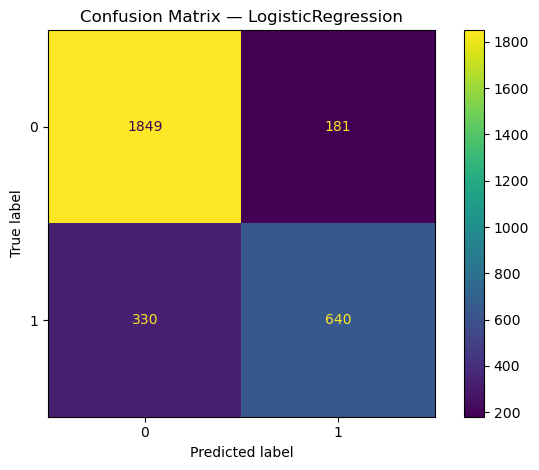

In [ ]:
models = {}
test_metrics = {}

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
models["Dummy(most_frequent)"] = dummy
m = evaluate_binary(dummy, X_test, y_test)
test_metrics["Dummy(most_frequent)"] = {k: v for k, v in m.items() if not k.startswith("_")}
print("Dummy metrics:", test_metrics["Dummy(most_frequent)"])

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
logreg.fit(X_train, y_train)
models["LogReg(Scaled)"] = logreg
m = evaluate_binary(logreg, X_test, y_test)
test_metrics["LogReg(Scaled)"] = {k: v for k, v in m.items() if not k.startswith("_")}
print("LogReg metrics:", test_metrics["LogReg(Scaled)"])

if m["_y_proba"] is not None:
    plot_and_save_roc(y_test, m["_y_proba"], "ROC — LogisticRegression", FIGURES_DIR / "roc_logreg.png")
plot_and_save_cm(logreg, X_test, y_test, "Confusion Matrix — LogisticRegression", FIGURES_DIR / "cm_logreg.png")


## 4) Модели недели 6 + честный подбор гиперпараметров (CV только на train)

Ниже:  
- `DecisionTreeClassifier` (контроль сложности: `max_depth`, `min_samples_leaf`, `ccp_alpha`)  
- `RandomForestClassifier` (лесные ручки: `max_depth`, `min_samples_leaf`, `max_features`)  
- `GradientBoostingClassifier` (boosting)

**Важно:** `GridSearchCV` делаем на `X_train, y_train`.  
`X_test, y_test` используем один раз — для финальной оценки лучших моделей.


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_summaries = {}

def run_gridsearch(name, estimator, param_grid, scoring="roc_auc"):
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    search_summaries[name] = {
        "best_params": gs.best_params_,
        "best_cv_score": float(gs.best_score_),
        "scoring": scoring,
        "n_splits": cv.get_n_splits(),
    }
    return best, gs


Best tree params: {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 20}
Tree test metrics: {'accuracy': 0.8633333333333333, 'f1': 0.7848898216159497, 'roc_auc': 0.9105332385353713}


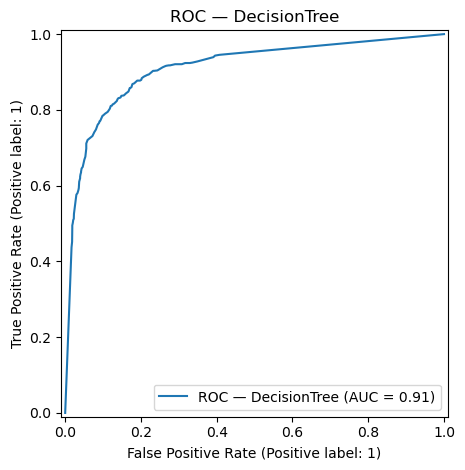

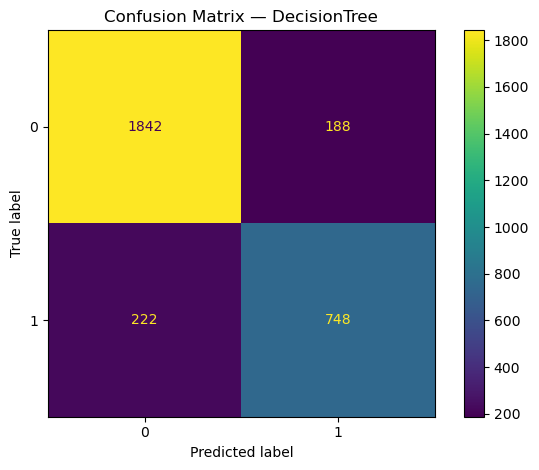

In [ ]:
# 4.1 Decision Tree with complexity control
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

param_grid_tree = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5, 20],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

best_tree, gs_tree = run_gridsearch("DecisionTree", tree, param_grid_tree, scoring="roc_auc")
models["DecisionTree(best_cv)"] = best_tree

m = evaluate_binary(best_tree, X_test, y_test)
test_metrics["DecisionTree(best_cv)"] = {k: v for k, v in m.items() if not k.startswith("_")}
print("Best tree params:", search_summaries["DecisionTree"]["best_params"])
print("Tree test metrics:", test_metrics["DecisionTree(best_cv)"])


if m["_y_proba"] is not None:
    plot_and_save_roc(y_test, m["_y_proba"], "ROC — DecisionTree", FIGURES_DIR / "roc_tree.png")
plot_and_save_cm(best_tree, X_test, y_test, "Confusion Matrix — DecisionTree", FIGURES_DIR / "cm_tree.png")


Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}
RF test metrics: {'accuracy': 0.9353333333333333, 'f1': 0.8952483801295896, 'roc_auc': 0.970270428114367}


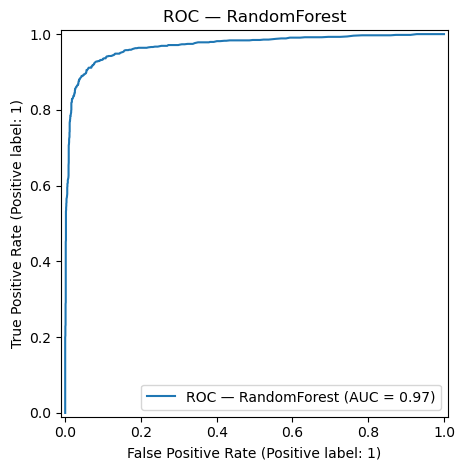

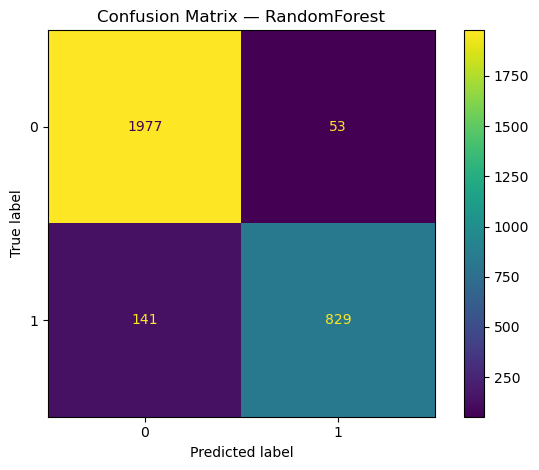

In [ ]:
# 4.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_rf = {
    "max_depth": [None, 6, 12],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
}

best_rf, gs_rf = run_gridsearch("RandomForest", rf, param_grid_rf, scoring="roc_auc")
models["RandomForest(best_cv)"] = best_rf

m = evaluate_binary(best_rf, X_test, y_test)
test_metrics["RandomForest(best_cv)"] = {k: v for k, v in m.items() if not k.startswith("_")}
print("Best RF params:", search_summaries["RandomForest"]["best_params"])
print("RF test metrics:", test_metrics["RandomForest(best_cv)"])


if m["_y_proba"] is not None:
    plot_and_save_roc(y_test, m["_y_proba"], "ROC — RandomForest", FIGURES_DIR / "roc_rf.png")
plot_and_save_cm(best_rf, X_test, y_test, "Confusion Matrix — RandomForest", FIGURES_DIR / "cm_rf.png")


Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
GB test metrics: {'accuracy': 0.9286666666666666, 'f1': 0.8861702127659574, 'roc_auc': 0.9682992229952768}


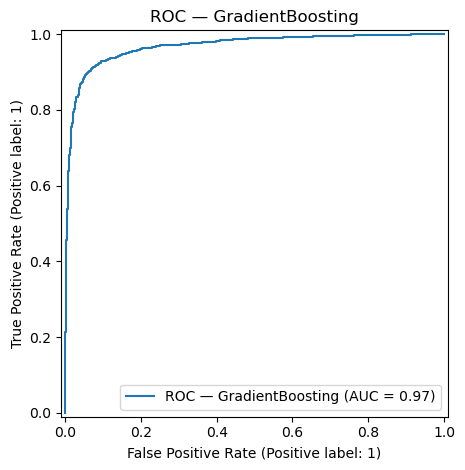

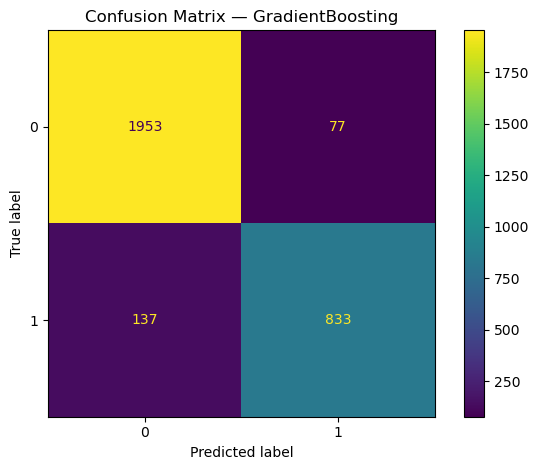

In [ ]:
# 4.3 Boosting: GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

param_grid_gb = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [1.0, 0.8],
}

best_gb, gs_gb = run_gridsearch("GradientBoosting", gb, param_grid_gb, scoring="roc_auc")
models["GradientBoosting(best_cv)"] = best_gb

m = evaluate_binary(best_gb, X_test, y_test)
test_metrics["GradientBoosting(best_cv)"] = {k: v for k, v in m.items() if not k.startswith("_")}
print("Best GB params:", search_summaries["GradientBoosting"]["best_params"])
print("GB test metrics:", test_metrics["GradientBoosting(best_cv)"])

if m["_y_proba"] is not None:
    plot_and_save_roc(y_test, m["_y_proba"], "ROC — GradientBoosting", FIGURES_DIR / "roc_gb.png")
plot_and_save_cm(best_gb, X_test, y_test, "Confusion Matrix — GradientBoosting", FIGURES_DIR / "cm_gb.png")


## 5) Сравнение моделей по метрикам на test

Собираем таблицу метрик и выбираем лучшую модель по **ROC-AUC** (для этого датасета бинарная задача).


In [20]:
metrics_df = pd.DataFrame(test_metrics).T
display(metrics_df.sort_values(by="roc_auc", ascending=False))

best_name = metrics_df["roc_auc"].astype(float).idxmax()
best_model = models[best_name]
best_row = metrics_df.loc[best_name].to_dict()

print("Best model by ROC-AUC on test:", best_name)
print("Best model test metrics:", best_row)


,accuracy,f1,roc_auc
RandomForest(best_cv),0.935333,0.895248,0.970270
GradientBoosting(best_cv),0.928667,0.886170,0.968299
DecisionTree(best_cv),0.863333,0.784890,0.910533
LogReg(Scaled),0.829667,0.714685,0.878909
Dummy(most_frequent),0.676667,0.000000,0.500000


Best model by ROC-AUC on test: RandomForest(best_cv)
Best model test metrics: {'accuracy': 0.9353333333333333, 'f1': 0.8952483801295896, 'roc_auc': 0.970270428114367}


## 6) Интерпретация лучшей модели: permutation importance

Считаем permutation importance на test (top-15) и сохраняем график в `artifacts/figures/`.


,feature,importance_mean,importance_std
18,num19,0.061928,0.003409
17,num18,0.048374,0.002696
6,num07,0.022234,0.000890
3,num04,0.013987,0.001533
19,num20,0.011381,0.001220
0,num01,0.008460,0.001048
23,num24,0.007640,0.000977
21,num22,0.006322,0.000757
7,num08,0.006130,0.000880
5,num06,0.005174,0.000943


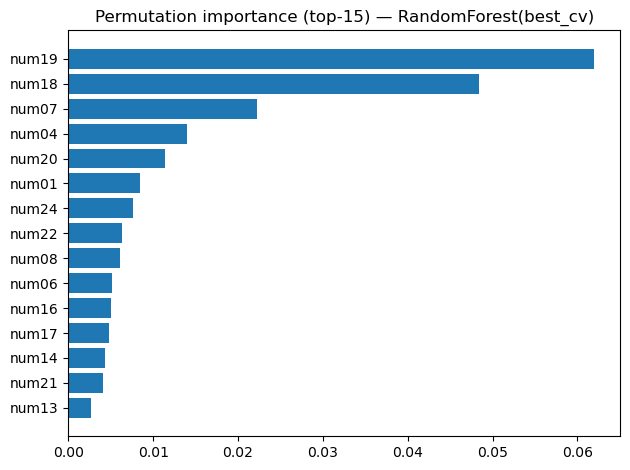

Saved: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\figures\permutation_importance.png


In [21]:
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="roc_auc"
)

imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

top_k = 15
display(imp.head(top_k))

plt.figure()
plt.barh(imp.head(top_k)["feature"][::-1], imp.head(top_k)["importance_mean"][::-1])
plt.title(f"Permutation importance (top-{top_k}) — {best_name}")
plt.tight_layout()
importance_path = FIGURES_DIR / "permutation_importance.png"
plt.savefig(importance_path, dpi=150)
plt.show()

print("Saved:", importance_path)


## 7) Сохранение артефактов

В `homeworks/HW06/artifacts/` сохраняем:
- `metrics_test.json` — метрики на test для всех моделей
- `search_summaries.json` — лучшие параметры и CV-score для моделей с подбором
- `best_model.joblib` — лучшая модель
- `best_model_meta.json` — метаданные лучшей модели
- `figures/` — минимум 2 графика (в этом ноутбуке сохраняем больше)


In [22]:
# 7.1 metrics_test.json
metrics_test_path = ARTIFACTS_DIR / "metrics_test.json"
save_json(test_metrics, metrics_test_path)
print("Saved:", metrics_test_path)

# 7.2 search_summaries.json
search_summaries_path = ARTIFACTS_DIR / "search_summaries.json"
save_json(search_summaries, search_summaries_path)
print("Saved:", search_summaries_path)

# 7.3 best_model.joblib
best_model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, best_model_path)
print("Saved:", best_model_path)

# 7.4 best_model_meta.json
best_model_meta = {
    "best_model_name": best_name,
    "best_model_params": best_model.get_params(),
    "selection_criterion": "roc_auc (test)",
    "test_metrics": best_row,
    "random_state": RANDOM_STATE,
    "train_test_split": {"test_size": 0.25, "stratify": True},
    "dataset": str(DATA_PATH),
}

best_model_meta_path = ARTIFACTS_DIR / "best_model_meta.json"
best_model_meta_serializable = dict(best_model_meta)
best_model_meta_serializable["best_model_params"] = {
    k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
    for k, v in best_model_meta["best_model_params"].items()
}

save_json(best_model_meta_serializable, best_model_meta_path)
print("Saved:", best_model_meta_path)

print("\nArtifacts directory listing:")
for root, dirs, files in os.walk(ARTIFACTS_DIR):
    level = str(root).replace(str(ARTIFACTS_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in sorted(files):
        print(f"{subindent}{f}")


Saved: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\metrics_test.json
Saved: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\search_summaries.json
Saved: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\best_model.joblib
Saved: C:\Users\anark\am-nom3\homeworks\HW06\artifacts\best_model_meta.json

Artifacts directory listing:
artifacts/
  best_model.joblib
  best_model_meta.json
  metrics_test.json
  search_summaries.json
  figures/
    cm_gb.png
    cm_logreg.png
    cm_rf.png
    cm_tree.png
    permutation_importance.png
    roc_gb.png
    roc_logreg.png
    roc_rf.png
    roc_tree.png


## 8) Короткие выводы

- Дерево решений легко переобучается, поэтому нужен контроль сложности (`max_depth`, `min_samples_leaf`, `ccp_alpha`).
- Bagging/RandomForest уменьшают variance (за счёт усреднения и случайности признаков).
- Boosting строит ансамбль последовательно и часто даёт лучший quality при разумных настройках.
- Честный эксперимент: тест используется **только один раз** после подбора гиперпараметров на train через CV.
